'''TASK 2·Customer Segmentation Analysis
Objective: Apply clustering algorithms to segment an e-commerce company's customer base into distinct groups based on purchasing behaviour, enabling targeted marketing strategies.'''

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

'''1.Load dataset and inspect structure; handle missing values and inconsistent data'''

In [2]:
df=pd.read_csv("C:/Users/Ayush Singh/OIBSIB/L1-CustSegmentation.csv")
print(f"Rows:{df.shape[0]}, Columns:{df.shape}")
print(f"Columns:{df.columns.tolist()}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nData Types:\n{df.dtypes}")

Rows:10000, Columns:(10000, 10)
Columns:['order_id', 'user_id', 'product_id', 'category', 'price', 'qty', 'total_price', 'order_date', 'country', 'customer_segment']

Missing Values:
order_id            0
user_id             0
product_id          0
category            0
price               0
qty                 0
total_price         0
order_date          0
country             0
customer_segment    0
dtype: int64

Data Types:
order_id              int64
user_id               int64
product_id            int64
category                str
price               float64
qty                   int64
total_price         float64
order_date              str
country                 str
customer_segment        str
dtype: object


In [3]:
#there's no missing values but still
df.dropna(subset=['user_id','order_date'])
if 'price' in df.columns:
    df['price'].fillna(df['price'].median())
if 'quantity' in df.columns:
    df['quantity'].fillna(df['quantity'].median())
if 'price' in df.columns:
    df=df[df['price']>0]
if 'quantity' in df.columns:
    df=df[df['quantity']>0]
df['order_date']=pd.to_datetime(df['order_date'],errors='coerce')
df.dropna(subset=['order_date'])
print(f"\nCleaned Rows:{df.shape[0]}")


Cleaned Rows:10000


'''2.Descriptive statistics:average purchase value, purchase frequency, customer lifetime value'''

In [4]:
if 'total_price' in df.columns:
    df['sales_amount']=df['total_price']
else:
    df['sales_amount']=df['price']*df['qty']
avg_purchase=df['sales_amount'].mean()
avg_frequency=df.groupby('user_id').size().mean()
avg_clv=df.groupby('user_id')['sales_amount'].sum().mean()
print("\nDESCRIPTIVE STATISTICS")
print(f"Average Purchase Value:${avg_purchase:.2f}")
print(f"Average Frequency:{avg_frequency:.2f} orders/customer")
print(f"Average CLV:${avg_clv:.2f}")


DESCRIPTIVE STATISTICS
Average Purchase Value:$159.58
Average Frequency:3.46 orders/customer
Average CLV:$552.19


'''3.Feature selection: identify 2–3 key behavioural features for clustering '''

In [5]:
snapshot_date= df['order_date'].max() + pd.Timedelta(days=1)
rfm = df.groupby('user_id').agg({
    'order_date': lambda x:(snapshot_date - x.max()).days,  # Recency
    'order_id': 'nunique',                                   # Frequency
    'sales_amount': 'sum'                                    # Monetary
}).reset_index()
rfm.columns = ['user_id', 'Recency', 'Frequency', 'Monetary']

'''4.Data normalisation/standardisation before clustering'''

In [6]:
scaler=StandardScaler()
rfm_scaled=scaler.fit_transform(rfm[['Recency','Frequency','Monetary']])

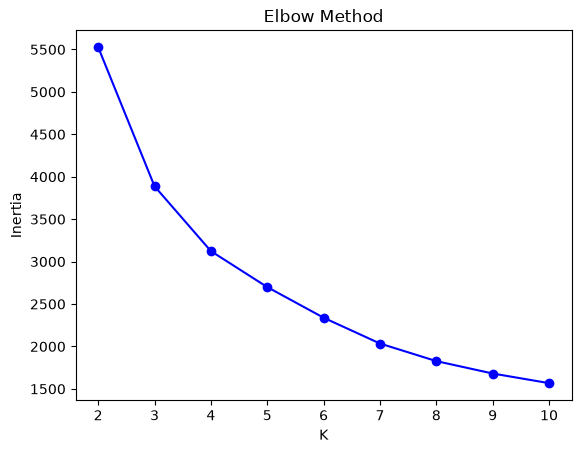

In [7]:
inertias=[]
K_range=range(2, 11)
for k in K_range:
    kmeans=KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertias.append(kmeans.inertia_)
plt.plot(K_range,inertias,'bo-')
plt.title('Elbow Method')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.show()
optimal_k = 4

In [8]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['Cluster']=kmeans.fit_predict(rfm_scaled)

In [9]:
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

'''6.Visualise clusters using scatter plots'''

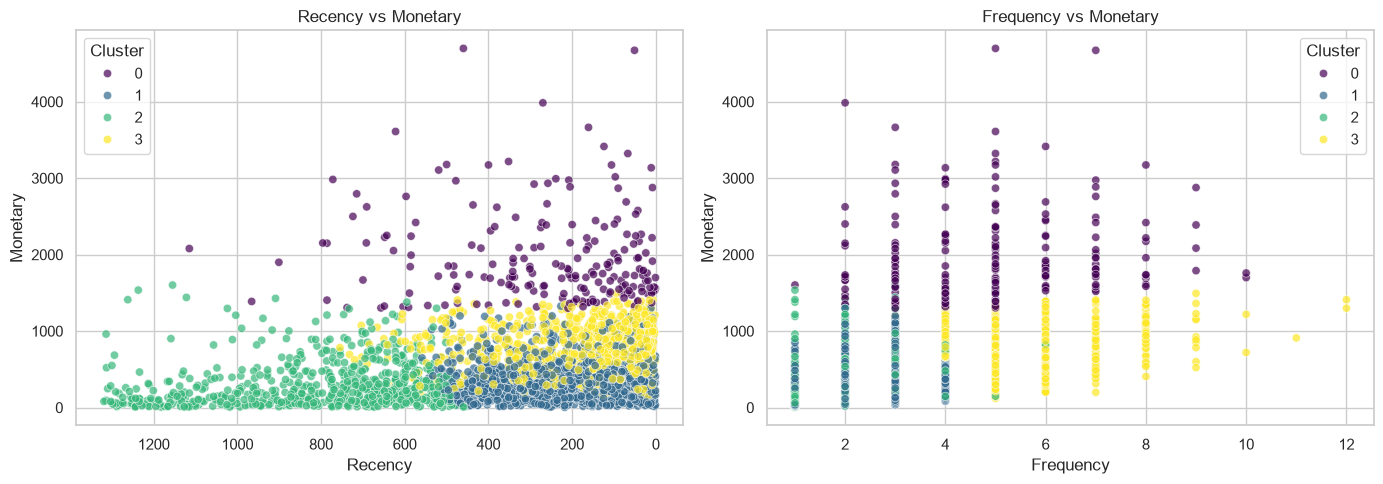

In [10]:
fig, axes=plt.subplots(1,2,figsize=(14,5))
sns.scatterplot(data=rfm,x='Recency',y='Monetary',hue='Cluster',palette='viridis',ax=axes[0],alpha=0.7)
axes[0].set_title('Recency vs Monetary')
axes[0].invert_xaxis()
sns.scatterplot(data=rfm,x='Frequency',y='Monetary',hue='Cluster',palette='viridis',ax=axes[1],alpha=0.7)
axes[1].set_title('Frequency vs Monetary')
plt.tight_layout()
plt.show()

'''7.Profile each cluster: calculate mean feature values per cluster and describe the customer type & barchart'''


CLUSTER PROFILES
            Recency  Frequency     Monetary
Cluster                                    
0        264.315271   4.763547  1967.885025
1        214.927760   2.759740   336.916347
2        792.039187   2.110305   295.484035
3        193.484334   5.455614   754.152833


C:\Users\Ayush Singh\AppData\Local\Temp\ipykernel_10640\3049553092.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm,x='Cluster',palette='viridis')


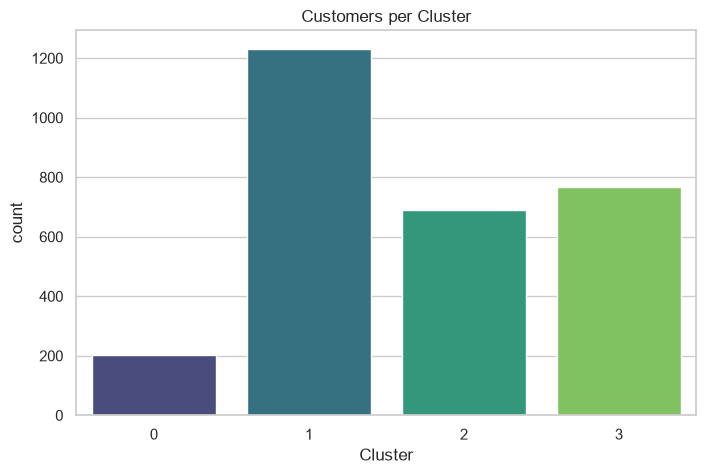

In [11]:
profile=rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()
counts=rfm['Cluster'].value_counts().sort_index()
print("\nCLUSTER PROFILES")
print(profile)
plt.figure(figsize=(8,5))
sns.countplot(data=rfm,x='Cluster',palette='viridis')
plt.title('Customers per Cluster')
plt.show()

In [12]:
#recommendation
med_r,med_f,med_m=rfm[['Recency','Frequency','Monetary']].median()
print("\nMARKETING INSIGHTS")
for i,row in profile.iterrows():
    cid=int(i)
    r,f,m=row['Recency'],row['Frequency'],row['Monetary']
    n=counts[cid]
    print(f"\nCluster {cid} ({n} customers): R={r:.1f}, F={f:.1f}, M=${m:.2f}")
    if r<med_r and f>med_f and m>med_m:
        print("Champions ->Action: Reward & Ask for Referrals")
    elif r>med_r and f>med_f and m>med_m:
        print("Loyals At-Risk ->Action: Personalized 'We Miss You' Offer")
    elif r<med_r and f<=med_f:
        print("New Customers ->Action: Welcome Series & Onboarding")
    elif r>med_r:
        print("Hibernating -> Action: Reactivation Campaign")
    else:
        print("Bargainers -> Action: Bundle Deals to Increase AOV")


MARKETING INSIGHTS

Cluster 0 (203 customers): R=264.3, F=4.8, M=$1967.89
Loyals At-Risk ->Action: Personalized 'We Miss You' Offer

Cluster 1 (1232 customers): R=214.9, F=2.8, M=$336.92
New Customers ->Action: Welcome Series & Onboarding

Cluster 2 (689 customers): R=792.0, F=2.1, M=$295.48
Hibernating -> Action: Reactivation Campaign

Cluster 3 (766 customers): R=193.5, F=5.5, M=$754.15
Champions ->Action: Reward & Ask for Referrals
